# Где дешевле жить? Предсказание цен в Airbnb

Работаем с [датасетом Airbnb по Нью-Йорку за 2019 год](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data). Задача — по характеристикам объявления угадать **цену за ночь** (`price`).

Краткое содержание результата

- Убрала цены которые выбивались из нормы: нули и объявления дороже 99-го перцентиля (там попадались $10 000 за ночь). 
- Обычная цена сильно растягивает график, но если взять логарифм цены (а потом вернуться обратно при изучении резульата), то распределение ровнее, и обработка для модели проще.
- Район, группа районов и тип жилья явно влияют на цену, поэтому я закодировала их черзе dummy
- Пропуски в reviews_per_month заполнила нулями, меньше нуля отзывов быть не может
- Посчитала логарифм количества отзывов, потому что первые отзывы актуальнее, чем все остальные (10 хороших отзывов, или 500 хороших отзывов суть одна - квартира неплохая за свою цену)

## Часть 1. EDA

In [15]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

### 1. Загружаем данные

Сначала смотрим, что вообще лежит в таблице. Колонки вроде `id`, `name`, `host_id`, `host_name` и `last_review` для предсказания цены не нужны — их сразу уберём.

In [16]:
df_raw = pd.read_csv('AB_NYC_2019.csv')
print(f'В датасете {df_raw.shape[0]} объявлений и {df_raw.shape[1]} колонок')
df_raw.head()

В датасете 48895 объявлений и 16 колонок


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [17]:
DROP_COLS = ['id', 'name', 'host_id', 'host_name', 'last_review']
df = df_raw.drop(columns=DROP_COLS)

print('Типы данных:')
print(df.dtypes)
print('\nПропуски:')
print(df.isnull().sum())
print('\nОписательная статистика числовых признаков:')
df.describe()

Типы данных:
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Пропуски:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Описательная статистика числовых признаков:


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Несколько графиков: как распределены числа, как цена зависит от района и типа жилья, есть ли связи между признаками.

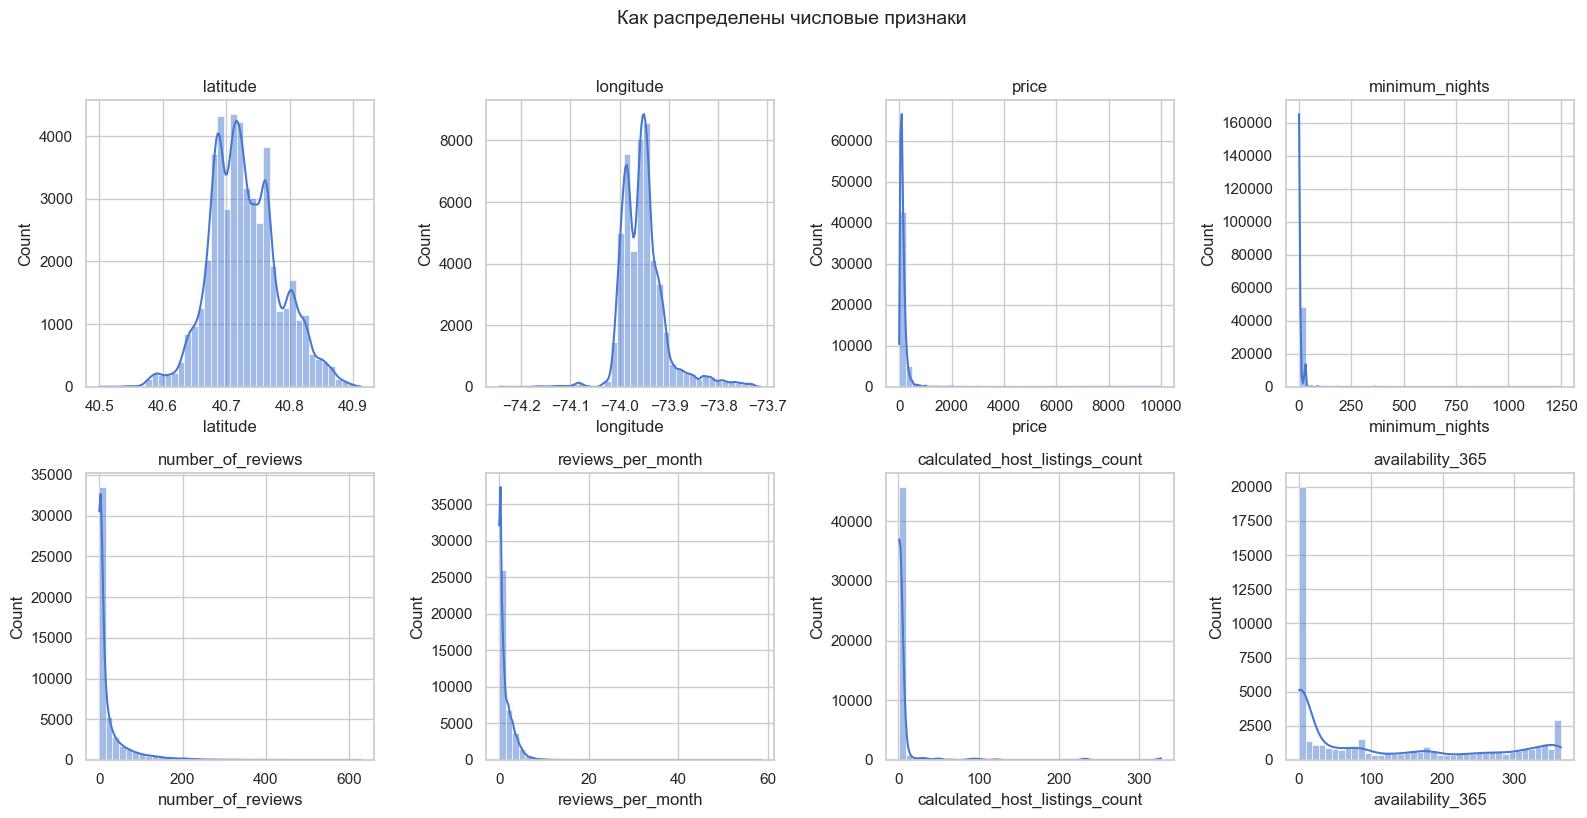

In [18]:
num_cols_eda = [
    'latitude', 'longitude', 'price', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols_eda):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Как распределены числовые признаки', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

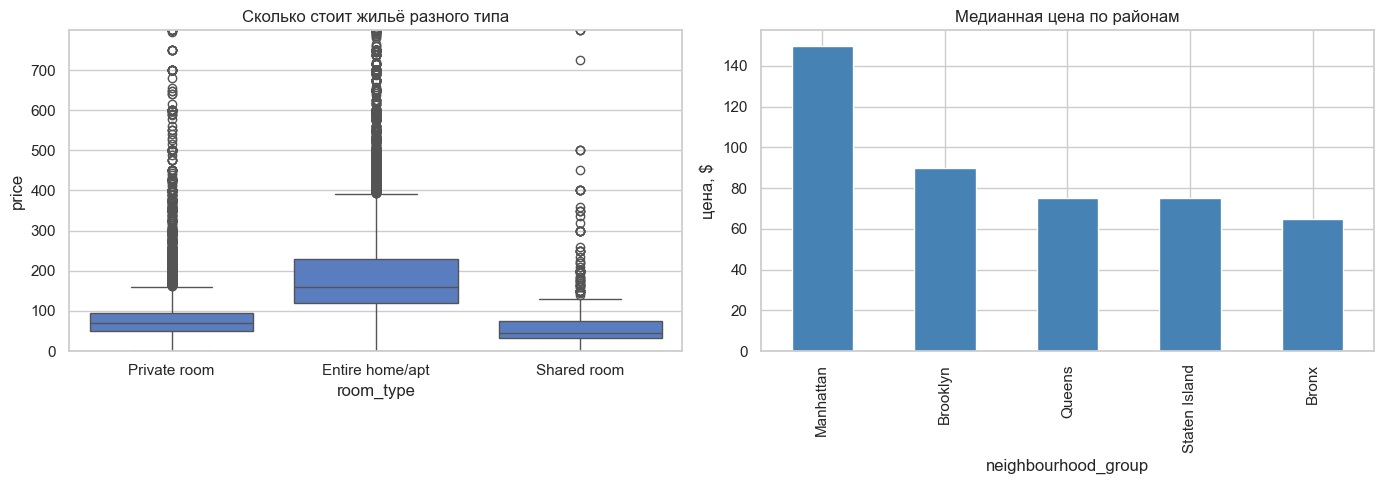

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='room_type', y='price', ax=axes[0])
axes[0].set_title('Сколько стоит жильё разного типа')
axes[0].set_ylim(0, df['price'].quantile(0.99))

price_by_group = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
price_by_group.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Медианная цена по районам')
axes[1].set_ylabel('цена, $')
plt.tight_layout()
plt.show()

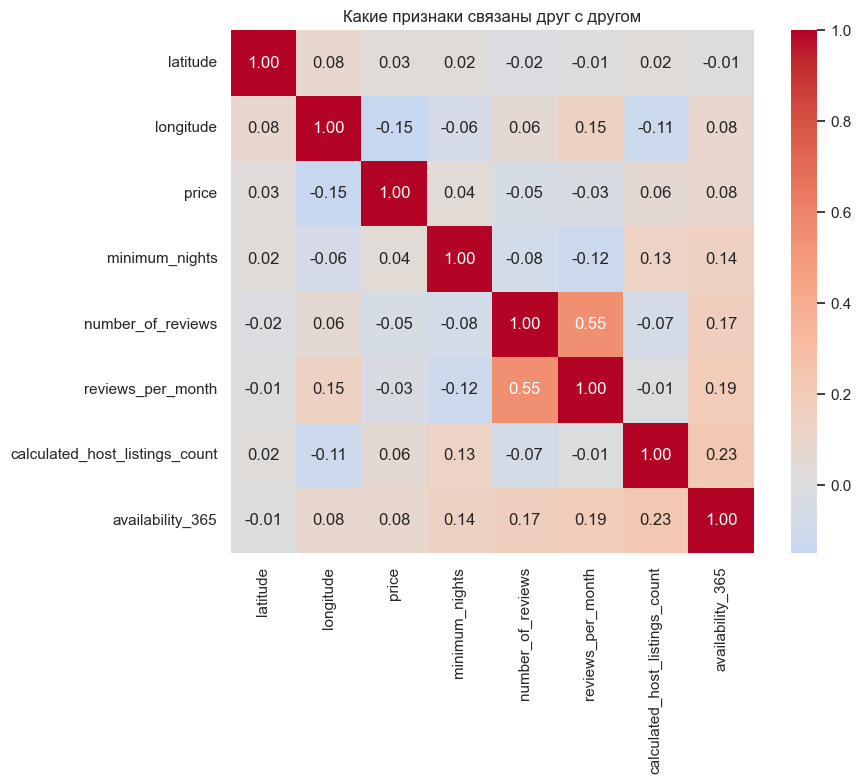

In [20]:
corr_cols = num_cols_eda
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Какие признаки связаны друг с другом')
plt.tight_layout()
plt.show()

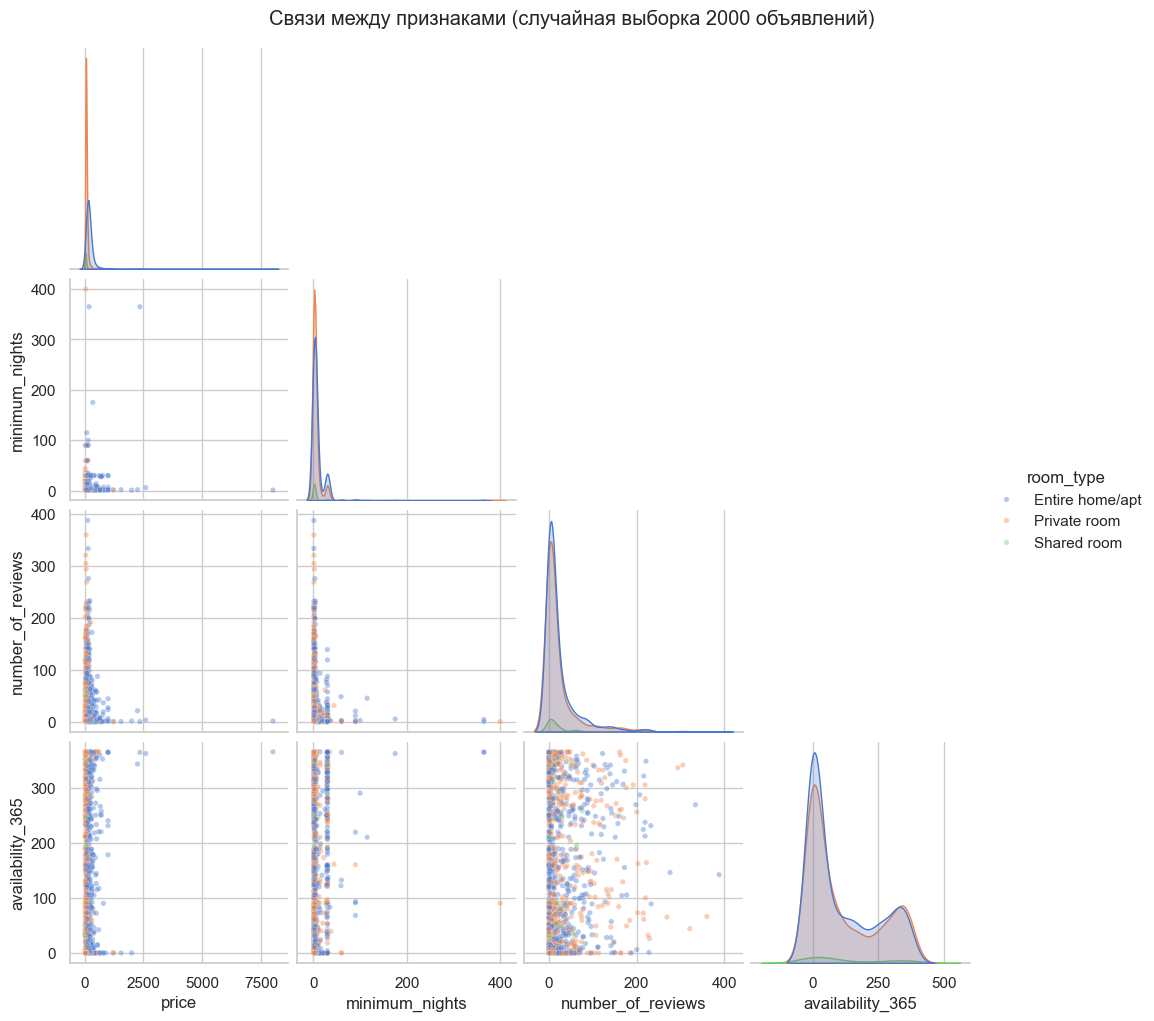

In [21]:
pair_cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'room_type']
sample_for_pair = df[pair_cols].sample(n=2000, random_state=RANDOM_STATE)

g = sns.pairplot(sample_for_pair, hue='room_type', diag_kind='kde', corner=True, plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle('Связи между признаками (случайная выборка 2000 объявлений)', y=1.02)
plt.show()

### 3. Что понятно после EDA

Главное, что бросается в глаза:

- **Цена** — слабый признак: много дешёвых объявлений и несколько с огромной ценой ($0 или $10 000), если не обработать то будут проблемы с обучением модели.
- Manhattan дороже всего, а среди типов жилья целая квартира (`Entire home/apt`) заметно дороже комнаты или места в shared room.
- У `minimum_nights` и `calculated_host_listings_count` длинные хвосты, поэтому для масштабирования стоит взять `RobustScaler` — он меньше реагирует на редкие большие значения.



Обработываю цены, добавляю новые колонки (логарифм ичества отзывов)

После очистки осталось 48410 объявлений из 48895
Убрано всё дороже $799 за ночь


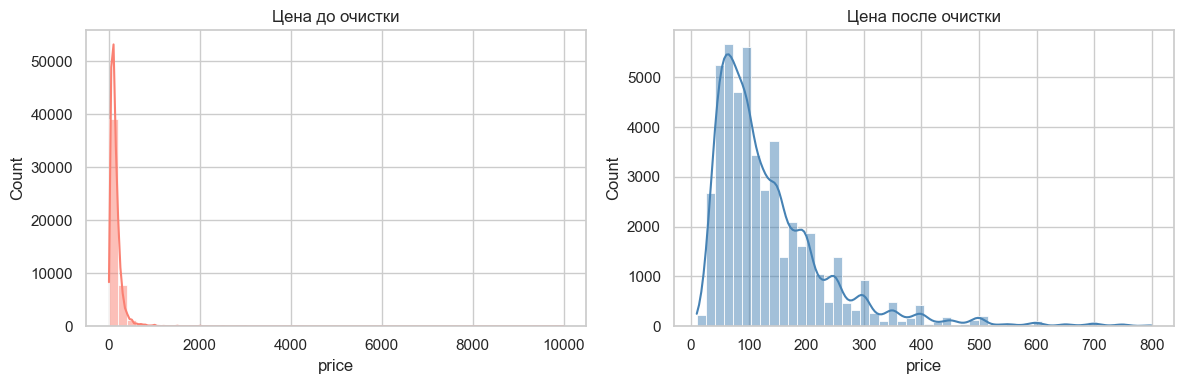

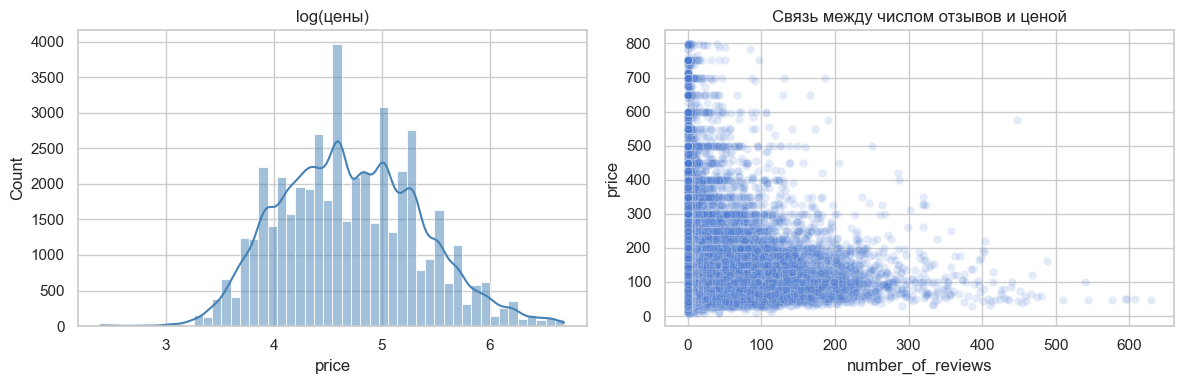

In [29]:
PRICE_CAP = 0.99
CAT_COLS = ['neighbourhood_group', 'neighbourhood', 'room_type']


def preprocess(df_in: pd.DataFrame) -> pd.DataFrame:
    data = df_in.drop(columns=DROP_COLS).copy()

    # минус нулевые и слишком дорогие объявления
    price_threshold = data['price'].quantile(PRICE_CAP)
    data = data[(data['price'] > 0) & (data['price'] <= price_threshold)]

    data['reviews_per_month'] = data['reviews_per_month'].fillna(0)
    data['log_reviews'] = np.log1p(data['number_of_reviews'])

    return data


df_clean = preprocess(df_raw)
print(f'После очистки осталось {df_clean.shape[0]} объявлений из {df_raw.shape[0]}')
print(f'Убрано всё дороже ${df_raw["price"].quantile(PRICE_CAP):.0f} за ночь')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw['price'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Цена до очистки')
sns.histplot(df_clean['price'], bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Цена после очистки')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log1p(df_clean['price']), bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('log(цены)')
sns.scatterplot(data=df_clean, x='number_of_reviews', y='price', alpha=0.15, ax=axes[1])
axes[1].set_title('Связь между числом отзывов и ценой')
plt.tight_layout()
plt.show()

In [23]:

def quick_ridge_score(scaler, use_engineered=True):
    data = preprocess(df_raw)
    if not use_engineered:
        data = data.drop(columns=['log_reviews'])
    y = np.log1p(data['price'])
    X = data.drop(columns=['price'])
    num_cols = [c for c in X.columns if c not in CAT_COLS]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE
    )
    pre = ColumnTransformer([
        ('num', scaler, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ])
    pipe = Pipeline([('pre', pre), ('model', RidgeCV(alphas=np.logspace(-2, 3, 30)))])
    pipe.fit(X_train, y_train)
    return r2_score(y_test, pipe.predict(X_test))


comparison = pd.DataFrame([
    {'scaler': 'StandardScaler', 'новые признаки': 'нет', 'R2': quick_ridge_score(StandardScaler(), False)},
    {'scaler': 'RobustScaler', 'новые признаки': 'нет', 'R2': quick_ridge_score(RobustScaler(), False)},
    {'scaler': 'StandardScaler', 'новые признаки': 'да', 'R2': quick_ridge_score(StandardScaler(), True)},
    {'scaler': 'RobustScaler', 'новые признаки': 'да', 'R2': quick_ridge_score(RobustScaler(), True)},
])
comparison

,scaler,новые признаки,R2
0,StandardScaler,нет,0.576765
1,RobustScaler,нет,0.576765
2,StandardScaler,да,0.577642
3,RobustScaler,да,0.577642


По таблице выше видно, что лучше всего сочетание **RobustScaler + новые признаки + логарифм цены**. 

Откладываю 30% данных на тест и сравниваю простую линейную регрессию с Ridge, Lasso и ElasticNet.

In [24]:
data = preprocess(df_raw)
y_log = np.log1p(data['price'])
y_price = data['price']
X = data.drop(columns=['price'])
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.3, random_state=RANDOM_STATE
)
y_test_price = np.expm1(y_test_log)

print(f'На обучение — {X_train.shape[0]} объявлений, на тест — {X_test.shape[0]}')
print(f'Числовых признаков: {len(NUM_COLS)}, категориальных: {len(CAT_COLS)}')

На обучение — 33887 объявлений, на тест — 14523
Числовых признаков: 8, категориальных: 3


In [25]:
def build_preprocessor():
    return ColumnTransformer([
        ('num', RobustScaler(), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ])


def evaluate_model(name, model):
    pipe = Pipeline([
        ('pre', build_preprocessor()),
        ('model', model),
    ])
    pipe.fit(X_train, y_train_log)
    pred_log = pipe.predict(X_test)
    pred_price = np.expm1(pred_log)

    return {
        'model': name,
        'R2 (log scale)': r2_score(y_test_log, pred_log),
        'MAE (USD)': mean_absolute_error(y_test_price, pred_price),
        'RMSE (USD)': np.sqrt(mean_squared_error(y_test_price, pred_price)),
        'pipeline': pipe,
    }


models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=np.logspace(-2, 3, 50)),
    'LassoCV': LassoCV(alphas=np.logspace(-3, 1, 50), max_iter=10000, random_state=RANDOM_STATE),
    'ElasticNetCV': ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
        alphas=np.logspace(-3, 1, 30),
        max_iter=10000,
        random_state=RANDOM_STATE,
    ),
}

results = [evaluate_model(name, model) for name, model in models.items()]
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipeline'} for r in results])
metrics_df = metrics_df.sort_values('R2 (log scale)', ascending=False).reset_index(drop=True)
metrics_df

,model,R2 (log scale),MAE (USD),RMSE (USD)
0,RidgeCV,0.577647,46.149480,80.084087
1,LinearRegression,0.576945,46.185684,80.095067
2,ElasticNetCV,0.574529,46.252770,80.397506
3,LassoCV,0.562561,46.850188,81.265126


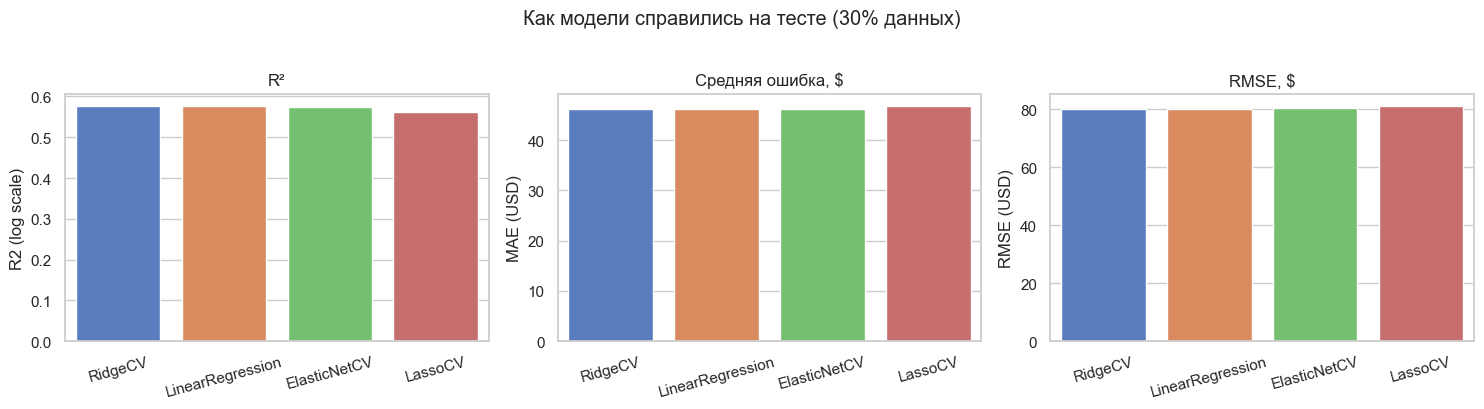

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = sns.color_palette('muted', n_colors=4)

for ax, metric, title in zip(
    axes,
    ['R2 (log scale)', 'MAE (USD)', 'RMSE (USD)'],
    ['R²', 'Средняя ошибка, $', 'RMSE, $'],
):
    ascending = metric != 'R2 (log scale)'
    plot_df = metrics_df.sort_values(metric, ascending=ascending)
    sns.barplot(data=plot_df, x='model', y=metric, ax=ax, palette=colors)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Как модели справились на тесте (30% данных)', y=1.02)
plt.tight_layout()
plt.show()

Лучшая модель — RidgeCV


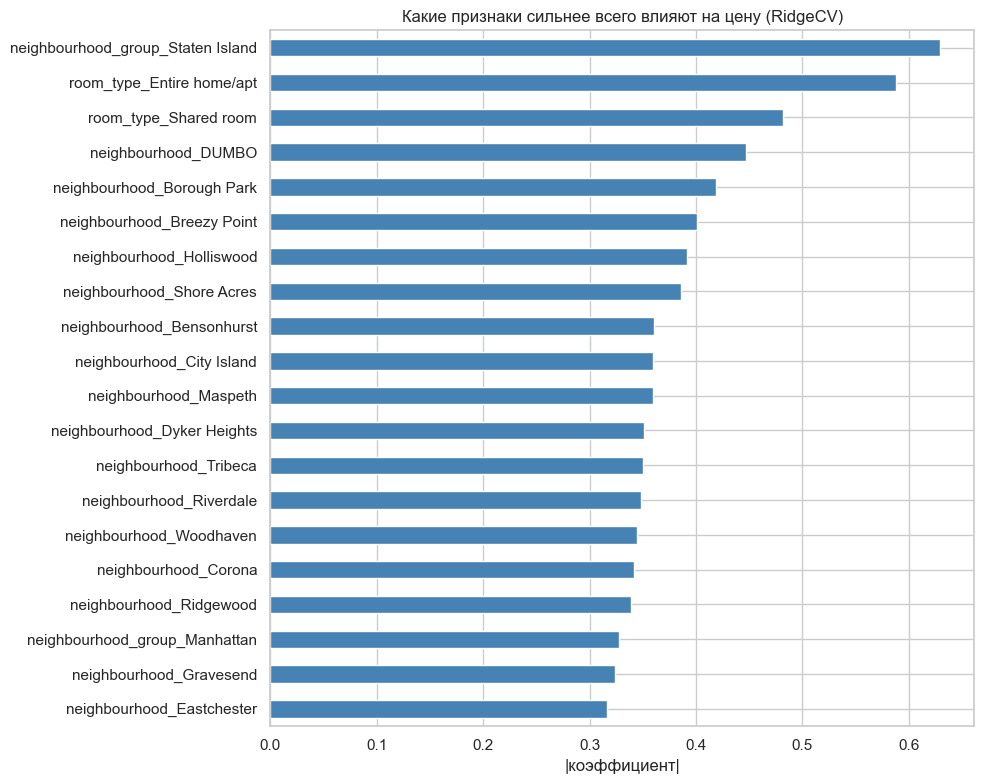

neighbourhood_group_Staten Island    0.629835
room_type_Entire home/apt            0.588308
room_type_Shared room                0.482205
neighbourhood_DUMBO                  0.446735
neighbourhood_Borough Park           0.418711
neighbourhood_Breezy Point           0.400692
neighbourhood_Holliswood             0.391698
neighbourhood_Shore Acres            0.385809
neighbourhood_Bensonhurst            0.360374
neighbourhood_City Island            0.359982
neighbourhood_Maspeth                0.359882
neighbourhood_Dyker Heights          0.351335
neighbourhood_Tribeca                0.349863
neighbourhood_Riverdale              0.348802
neighbourhood_Woodhaven              0.344317
dtype: float64

In [27]:
def get_feature_names(preprocessor):
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_COLS)
    return list(NUM_COLS) + list(cat_names)


def plot_feature_importance(pipeline, model_name, top_n=20):
    pre = pipeline.named_steps['pre']
    coefs = pipeline.named_steps['model'].coef_
    feature_names = get_feature_names(pre)

    importance = pd.Series(np.abs(coefs), index=feature_names).sort_values(ascending=False)
    top = importance.head(top_n).sort_values()

    plt.figure(figsize=(10, 8))
    top.plot(kind='barh', color='steelblue')
    plt.title(f'Какие признаки сильнее всего влияют на цену ({model_name})')
    plt.xlabel('|коэффициент|')
    plt.tight_layout()
    plt.show()

    return importance


best_result = max(results, key=lambda r: r['R2 (log scale)'])
best_pipe = best_result['pipeline']
best_name = best_result['model']
print(f'Лучшая модель — {best_name}')

importance = plot_feature_importance(best_pipe, best_name)
importance.head(15)

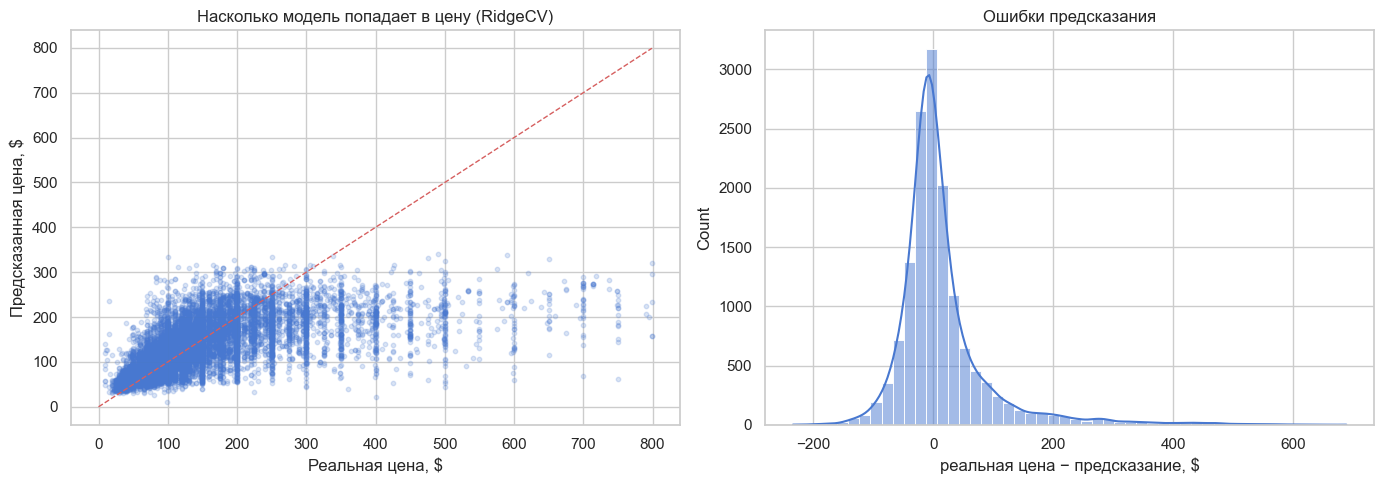

In [28]:
pred_log = best_pipe.predict(X_test)
pred_price = np.expm1(pred_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_price, pred_price, alpha=0.2, s=10)
max_val = max(y_test_price.max(), pred_price.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1)
axes[0].set_xlabel('Реальная цена, $')
axes[0].set_ylabel('Предсказанная цена, $')
axes[0].set_title(f'Насколько модель попадает в цену ({best_name})')

residuals = y_test_price - pred_price
sns.histplot(residuals, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Ошибки предсказания')
axes[1].set_xlabel('реальная цена − предсказание, $')
plt.tight_layout()
plt.show()

## Выводы

Признак где стоит квартира то есть район (`neighbourhood`, `neighbourhood_group`)  сильнее остальных признаков. В нью йорке цена сильно зависит от локации, манхетен самый дорогой.

Тип жилья тоже сильно влияет Целая квартира стоит дороже отдельной комнаты, а shared room — самый бюджетный вариант. На графиках это видно сразу, и модель это увидела.

Из моделей лучше всего RidgeCV. Разница с обычной линейной регрессией небольшая, но Ridge чуть стабильнее — видимо, из-за большого числа dummy-признаков по районам. Лассо по R² чуть хуже, ElasticNet где-то посередине.

Обычная ошибка около $46 за ночь. Для недорогих объявлений в квинсе или бронксе модель попадает неплохо. Хуже всего с очень дорогими квартирами в манхетене — на scatter-plot видно, что модель их часто недооценивает.